# Подготовка

In [1]:
import random, os

import numpy as np
import torch

from torch import nn
from torch.utils.data import DataLoader, random_split, Subset
from torch.optim import SGD, Adam, AdamW

import torchvision.transforms as T
from torchvision.datasets import ImageFolder

import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

from IPython.display import clear_output, display

from PIL import Image

In [2]:
import wandb
wandb.login()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\anton\_netrc.
wandb: Currently logged in as: qwelly (some_ml) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

## Сиды

In [4]:
def set_global_seed(seed: int) -> None:
    """Set global seed for reproducibility.
    :param int seed: Seed to be set
    """
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

    # также можно зафиксировать seed для Dataloader
    g = torch.Generator()
    g.manual_seed(seed)
    return g

# Сид для каждого worker в Dataloader
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = set_global_seed(739)

## Фильтрация изображений

In [5]:
root = "PetImages"

for category in ["Cat", "Dog"]:
    folder = os.path.join(root, category)

    for filename in os.listdir(folder):
        path = os.path.join(folder, filename)

        try:
            with Image.open(path) as img:
                img.verify()
        except:
            print(f"Удаляем: {path} ({e})")
            os.remove(path)

C:\Users\anton\miniconda3\envs\ML-FKN\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


## Данные

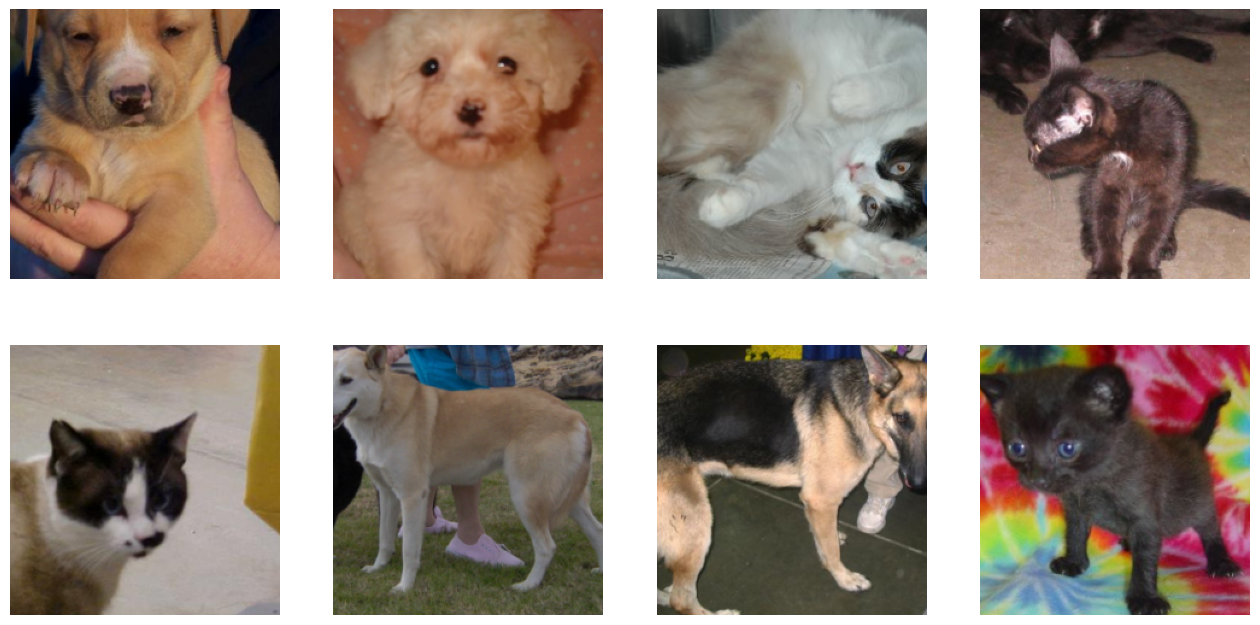

In [6]:
show_transforms = T.Compose(
    [
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
    ]
)

dataset = ImageFolder(
    "PetImages",
    transform=show_transforms,
)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.ravel()

for i, ax in enumerate(axes):
    rand_index = np.random.randint(0, len(dataset))
    img = dataset.__getitem__(rand_index)[0].permute((1, 2, 0))
    ax.imshow(img)
    ax.axis("off")

plt.show()

### Трансформации и аугментации

In [7]:
norm = T.Normalize(
    [0.485, 0.486, 0.406],
    [0.229, 0.224, 0.225]
)

aug_transforms = T.Compose(
    [
        T.RandomResizedCrop(224),
        T.RandomHorizontalFlip(p=0.5),
        T.ToTensor(),
        norm,
    ]
)

base_transforms = T.Compose(
    [
        T.Resize(256),
        T.CenterCrop(224),
        T.ToTensor(),
        norm,
    ]
)

In [8]:
train_, test_ = random_split(
    range(len(dataset)),
    lengths=[0.7, 0.3],
)

train_set = ImageFolder(
    "PetImages",
    transform=aug_transforms,
)

test_set = ImageFolder(
    "PetImages",
    transform=base_transforms,
)

train_set = Subset(train_set, train_.indices)
test_set = Subset(test_set, test_.indices)

train_set, val_set = random_split(
    train_set,
    lengths=[0.75, 0.25]
)

In [9]:
print(f"Original dataset: {len(dataset)}")
print(f"Train dataset: {len(train_set)}")
print(f"Validation dataset: {len(val_set)}")
print(f"Test dataset: {len(test_set)}")

Original dataset: 24998
Train dataset: 13125
Validation dataset: 4374
Test dataset: 7499


# Модели

## PetsBattleCNN (на основе AlexNet)

In [10]:
class PetsBattleCNN(nn.Module):

    def __init__(self, channels=3):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=channels, out_channels=48, kernel_size=11, stride=4),
            nn.BatchNorm2d(48),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=48, out_channels=128, kernel_size=5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=128, out_channels=192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),
            
            nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(),

            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Flatten(),
        )

        self.classifier = nn.Sequential(
            nn.LazyLinear(out_features=1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout1d(p=0.1),
            
            nn.Linear(in_features=1024 ,out_features=128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout1d(p=0.1),
            
            nn.Linear(in_features=128, out_features=2),
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.classifier(features)

    def get_embedding(self, x):
        return self.encoder(x)

# Цикл обучения

In [11]:
def train_epoch(model, dataloader, loss_func, optimizer):

    model.train()

    epoch_accuracy = 0
    epoch_loss = 0
    
    batch_size = dataloader.batch_size
    dataset_size = len(dataloader.dataset)

    for x_batch, y_batch in tqdm(dataloader, desc="train"):

        model.zero_grad()
        
        x = x_batch.to(device)
        y = y_batch.to(device)

        out = model(x)
        loss = loss_func(out, y)

        loss.backward()
        optimizer.step()

        wandb.log(
            {"train/batch-loss": loss.item()}
        )

        epoch_accuracy += (out.argmax(dim=1) == y).sum().item()
        epoch_loss += loss.item() * batch_size

    epoch_accuracy /= dataset_size
    epoch_loss /= dataset_size

    return epoch_accuracy, epoch_loss


@torch.no_grad()
def validate_epoch(model, dataloader, loss_func):

    model.eval()

    epoch_accuracy = 0
    epoch_loss = 0
    
    batch_size = dataloader.batch_size
    dataset_size = len(dataloader.dataset)

    for x_batch, y_batch in tqdm(dataloader, desc="valid"):
        
        x = x_batch.to(device)
        y = y_batch.to(device)

        out = model(x)
        loss = loss_func(out, y)

        epoch_accuracy += (out.argmax(dim=1) == y).sum().item()
        epoch_loss += loss.item() * batch_size

    epoch_accuracy /= dataset_size
    epoch_loss /= dataset_size

    return epoch_accuracy, epoch_loss


def train(model, train_loader, val_loader, loss_func, optimizer, num_epochs, early_stop_epochs=None):

    prev_val_loss = None
    accuracy_best_model = None
    loss_best_model = None
    best_state = None
    stop_points = 0
    
    for epoch in range(1, num_epochs+1):
        clear_output()        
        print(f"EPOCH {epoch}:")

        train_accuracy, train_loss = train_epoch(model, train_loader, loss_func, optimizer)
        val_accuracy, val_loss = validate_epoch(model, val_loader, loss_func)

        if (early_stop_epochs is not None) and (prev_val_loss is not None):
            if (val_loss >= prev_val_loss) or np.isclose(prev_val_loss, val_loss, atol=1e-5):
                stop_points += 1

        with torch.no_grad():
            if (accuracy_best_model is None) or (val_accuracy > accuracy_best_model):
                accuracy_best_model = val_accuracy
                loss_best_model = val_loss
                stop_points = 0
                best_state = {
                    k: v.cpu().clone()
                    for k, v in model.state_dict().items()
                }
                
        prev_val_loss = val_loss

        wandb.log(
            {
                "train/epoch-accuracy": train_accuracy,
                "train/epoch-loss": train_loss,
                "validate/epoch-accuracy": val_accuracy,
                "validate/epoch-loss": val_loss,
            }
        )

        if (early_stop_epochs is not None) and (stop_points >= early_stop_epochs):
            print(f"Early stopped on {epoch} epoch")
            break

    model.load_state_dict(best_state)
    return {"Accuracy best model": accuracy_best_model, "Loss best model": loss_best_model}

# Обучение

In [12]:
g = set_global_seed(739)

BATCH_SIZE = 128
LR = 1e-3
WD = 1e-5
NUM_EPOCHS = 10

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_set,
    batch_size=4096,
    shuffle=False,
    pin_memory=True,
)

model = PetsBattleCNN().to(device)
# Инициализация LazyLinear
for x_batch, y_batch in train_loader:
    model(x_batch.to(device))
    break

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)

loss_func = nn.CrossEntropyLoss()

config = {
    "architecture": 'AlexNet',
    "optimizer": 'AdamW',
    "learning_rate": LR,
    "weight_decay": WD,
    "scheduler": 'None',
    "epochs":  NUM_EPOCHS,
}

wandb.init(
    project="Cats vs Dogs",
    name="PetsBattleCNN",
    config=config
)

try:
    print(train(model, train_loader, val_loader, loss_func, optimizer, NUM_EPOCHS, 5))
finally:
    wandb.finish()

EPOCH 10:


train:   0%|          | 0/103 [00:00<?, ?it/s]

valid:   0%|          | 0/2 [00:00<?, ?it/s]

{'Accuracy best model': 0.799039780521262, 'Loss best model': 0.7737567973126}


train/batch-loss,█▆▆▆▆▆▄▄▅▅▃▂▄▄▆▄▂▄▄▄▂▃▃▃▄▃▄▃▃▃▁▂▄▁▁▂▄▃▂▂
train/epoch-accuracy,▁▃▅▅▆▇▇▇██
train/epoch-loss,█▆▆▅▄▃▂▂▁▁
validate/epoch-accuracy,▁▁▃▅▅▄▅▅█▆
validate/epoch-loss,██▇▅▅▅▄▃▁▄
train/batch-loss,0.47663
train/epoch-accuracy,0.7443
train/epoch-loss,0.4738
validate/epoch-accuracy,0.74851
validate/epoch-loss,0.93292


# Файнтюнинг

In [13]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
print(sum((param.numel() for param in model.parameters())))

11689512


In [14]:
g = set_global_seed(739)

BATCH_SIZE = 128
LR = 1e-3
WD = 1e-3
NUM_EPOCHS = 10

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(512, 2)
model.to(device)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_set,
    batch_size=1024,
    shuffle=False,
    pin_memory=True,
)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)

loss_func = nn.CrossEntropyLoss()

config = {
    "architecture": 'ResNet18',
    "pre-training": "finetuning image_net",
    "optimizer": 'AdamW',
    "learning_rate": LR,
    "weight_decay": WD,
    "scheduler": 'None',
    "epochs":  NUM_EPOCHS,
}

wandb.init(
    project="Cats vs Dogs",
    name="ResNet FineTuning",
    config=config
)

try:
    print(train(model, train_loader, val_loader, loss_func, optimizer, NUM_EPOCHS, 5))
finally:
    wandb.finish()

EPOCH 10:


train:   0%|          | 0/103 [00:00<?, ?it/s]

valid:   0%|          | 0/5 [00:00<?, ?it/s]

{'Accuracy best model': 0.9348422496570644, 'Loss best model': 0.165985869663624}


train/batch-loss,█▅▇█▄▄█▂▅▇▃▄█▃▄▄▁▆▄▅▂▆▆▁▃▅█▁▂▃▂▂▂▂▃▄▂▅▂▂
train/epoch-accuracy,▁▅▆▆▆▇▇███
train/epoch-loss,█▅▃▃▃▃▂▁▁▁
validate/epoch-accuracy,▆▇▁▇▇▇▇█▆▇
validate/epoch-loss,▂▂█▂▂▂▂▁▂▁
train/batch-loss,0.13799
train/epoch-accuracy,0.94133
train/epoch-loss,0.13134
validate/epoch-accuracy,0.92661
validate/epoch-loss,0.189


# Transfer Learning

In [15]:
from torchvision.models import resnet18, ResNet18_Weights

In [17]:
g = set_global_seed(739)

BATCH_SIZE = 128
LR = 1e-3
WD = 1e-3
NUM_EPOCHS = 10

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(512, 2)
model.to(device)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_set,
    batch_size=1024,
    shuffle=False,
    pin_memory=True,
)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)

loss_func = nn.CrossEntropyLoss()

config = {
    "architecture": 'ResNet18',
    "pre-training": "transfer learning image_net",
    "optimizer": 'AdamW',
    "learning_rate": LR,
    "weight_decay": WD,
    "scheduler": 'None',
    "epochs":  NUM_EPOCHS,
}

wandb.init(
    project="Cats vs Dogs",
    name="ResNet TransferLearning",
    config=config
)

try:
    print(train(model, train_loader, val_loader, loss_func, optimizer, NUM_EPOCHS, 5))
finally:
    wandb.finish()

EPOCH 10:


train:   0%|          | 0/103 [00:00<?, ?it/s]

valid:   0%|          | 0/5 [00:00<?, ?it/s]

{'Accuracy best model': 0.9545038866026521, 'Loss best model': 0.12331368228753625}


train/batch-loss,██▇▅▅▄▃▇▅▅▄▃▅▆▃▄▃▃▂▃▁▁▄▄▂▄▄▂▂▃▄▄▁▃▂▂▂▆▄▂
train/epoch-accuracy,▁▆▇▇▇▇▇▇██
train/epoch-loss,█▃▂▂▂▂▁▁▁▁
validate/epoch-accuracy,▁▅▅▄▄▇▆▃▅█
validate/epoch-loss,█▄▅▅▅▂▂▄▄▁
train/batch-loss,0.2852
train/epoch-accuracy,0.9539
train/epoch-loss,0.11149
validate/epoch-accuracy,0.9545
validate/epoch-loss,0.12331


Лучше всего обучается ResNet с Transfer Learning

# Тест

In [18]:
g = set_global_seed(739)

BATCH_SIZE = 128
LR = 1e-3
WD = 1e-3
NUM_EPOCHS = 30

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc = nn.Linear(512, 2)
model.to(device)

train_loader = DataLoader(
    train_set,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=True,
    worker_init_fn=seed_worker,
)

val_loader = DataLoader(
    val_set,
    batch_size=1024,
    shuffle=False,
    pin_memory=True,
)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WD)

loss_func = nn.CrossEntropyLoss()

config = {
    "architecture": 'ResNet18',
    "pre-training": "transfer learning image_net",
    "optimizer": 'AdamW',
    "learning_rate": LR,
    "weight_decay": WD,
    "scheduler": 'None',
    "epochs":  NUM_EPOCHS,
}

wandb.init(
    project="Cats vs Dogs",
    name="ResNet TransferLearning",
    config=config
)

try:
    print(train(model, train_loader, val_loader, loss_func, optimizer, NUM_EPOCHS, 5))
finally:
    wandb.finish()

EPOCH 23:


train:   0%|          | 0/103 [00:00<?, ?it/s]

valid:   0%|          | 0/5 [00:00<?, ?it/s]

Early stopped on 23 epoch
{'Accuracy best model': 0.9556470050297211, 'Loss best model': 0.12439535042440504}


train/batch-loss,█▂▂▂▂▁▁▁▂▁▁▁▁▁▂▂▁▂▂▂▂▁▁▁▂▂▁▂▂▁▂▂▁▁▂▂▁▁▁▂
train/epoch-accuracy,▁▆▇▇▇▇▇▇███▇▇▇████▇████
train/epoch-loss,█▃▂▂▂▂▂▂▁▁▁▂▁▂▁▁▁▁▁▁▁▁▁
validate/epoch-accuracy,▁▅▄▄▄▇▆▃▄█▆▇▆█▆▆█▇▆▇▇▇▅
validate/epoch-loss,█▄▅▅▅▂▂▄▄▁▃▂▃▁▂▃▁▂▂▂▂▁▂
train/batch-loss,0.17339
train/epoch-accuracy,0.95078
train/epoch-loss,0.10924
validate/epoch-accuracy,0.94833
validate/epoch-loss,0.12845


In [20]:
test_loader = DataLoader(
    test_set,
    batch_size=1024,
    shuffle=False,
    pin_memory=True,
)
loss_func = nn.CrossEntropyLoss()

acc, loss = validate_epoch(model, test_loader, loss_func)
print(f"Test accurasy = {acc}, Test loss = {loss}")

valid:   0%|          | 0/8 [00:00<?, ?it/s]

Test accurasy = 0.9821309507934392, Test loss = 0.0522066943724007
